In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [8]:
df = pd.read_csv("df_encode_dropped_columns.csv")
df

,Age,Attrition,DistanceFromHome,Education,HourlyRate,JobInvolvement,JobLevel,NumCompaniesWorked,OverTime,PercentSalaryHike,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,0,1,2,94,3,2,8,1,11,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,49,1,8,1,61,2,2,1,0,23,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,0,2,2,92,2,1,6,1,15,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,33,1,3,4,56,3,1,1,1,11,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,27,1,2,1,40,3,1,9,0,12,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,1,23,2,41,4,2,4,0,17,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1466,39,1,6,1,42,2,3,4,0,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1467,27,1,4,3,87,4,2,1,1,20,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1468,49,1,2,3,63,2,2,2,0,14,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [9]:
features = df.drop(columns = ["Attrition"])
target = df["Attrition"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

In [11]:
normalizer = MinMaxScaler()

normalizer.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](31,)","[60.,29., 5.,..., 1., 1., 1.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](31,)","[18., 1., 1.,..., 0., 0., 0.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](31,)","[42.,28., 4.,..., 1., 1., 1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](31,)","['Age','DistanceFromHome','Education',...,'JobRole_Sales Representative', 'MaritalStatus_Married','MaritalStatus_Single']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](31,)","[-0.43,-0.04,-0.25,..., 0. , 0. , 0. ]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,31
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,1176


In [12]:
X_train_norm = normalizer.transform(X_train)

X_test_norm = normalizer.transform(X_test)

X_train_norm

array([[0.95238095, 0.71428571, 0.5       , ..., 0.        , 1.        ,
        0.        ],
       [0.64285714, 0.96428571, 0.5       , ..., 0.        , 1.        ,
        0.        ],
       [0.52380952, 0.89285714, 0.5       , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.5952381 , 0.03571429, 0.5       , ..., 0.        , 1.        ,
        0.        ],
       [0.47619048, 0.03571429, 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.52380952, 0.32142857, 0.75      , ..., 0.        , 0.        ,
        0.        ]], shape=(1176, 31))

In [13]:
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)

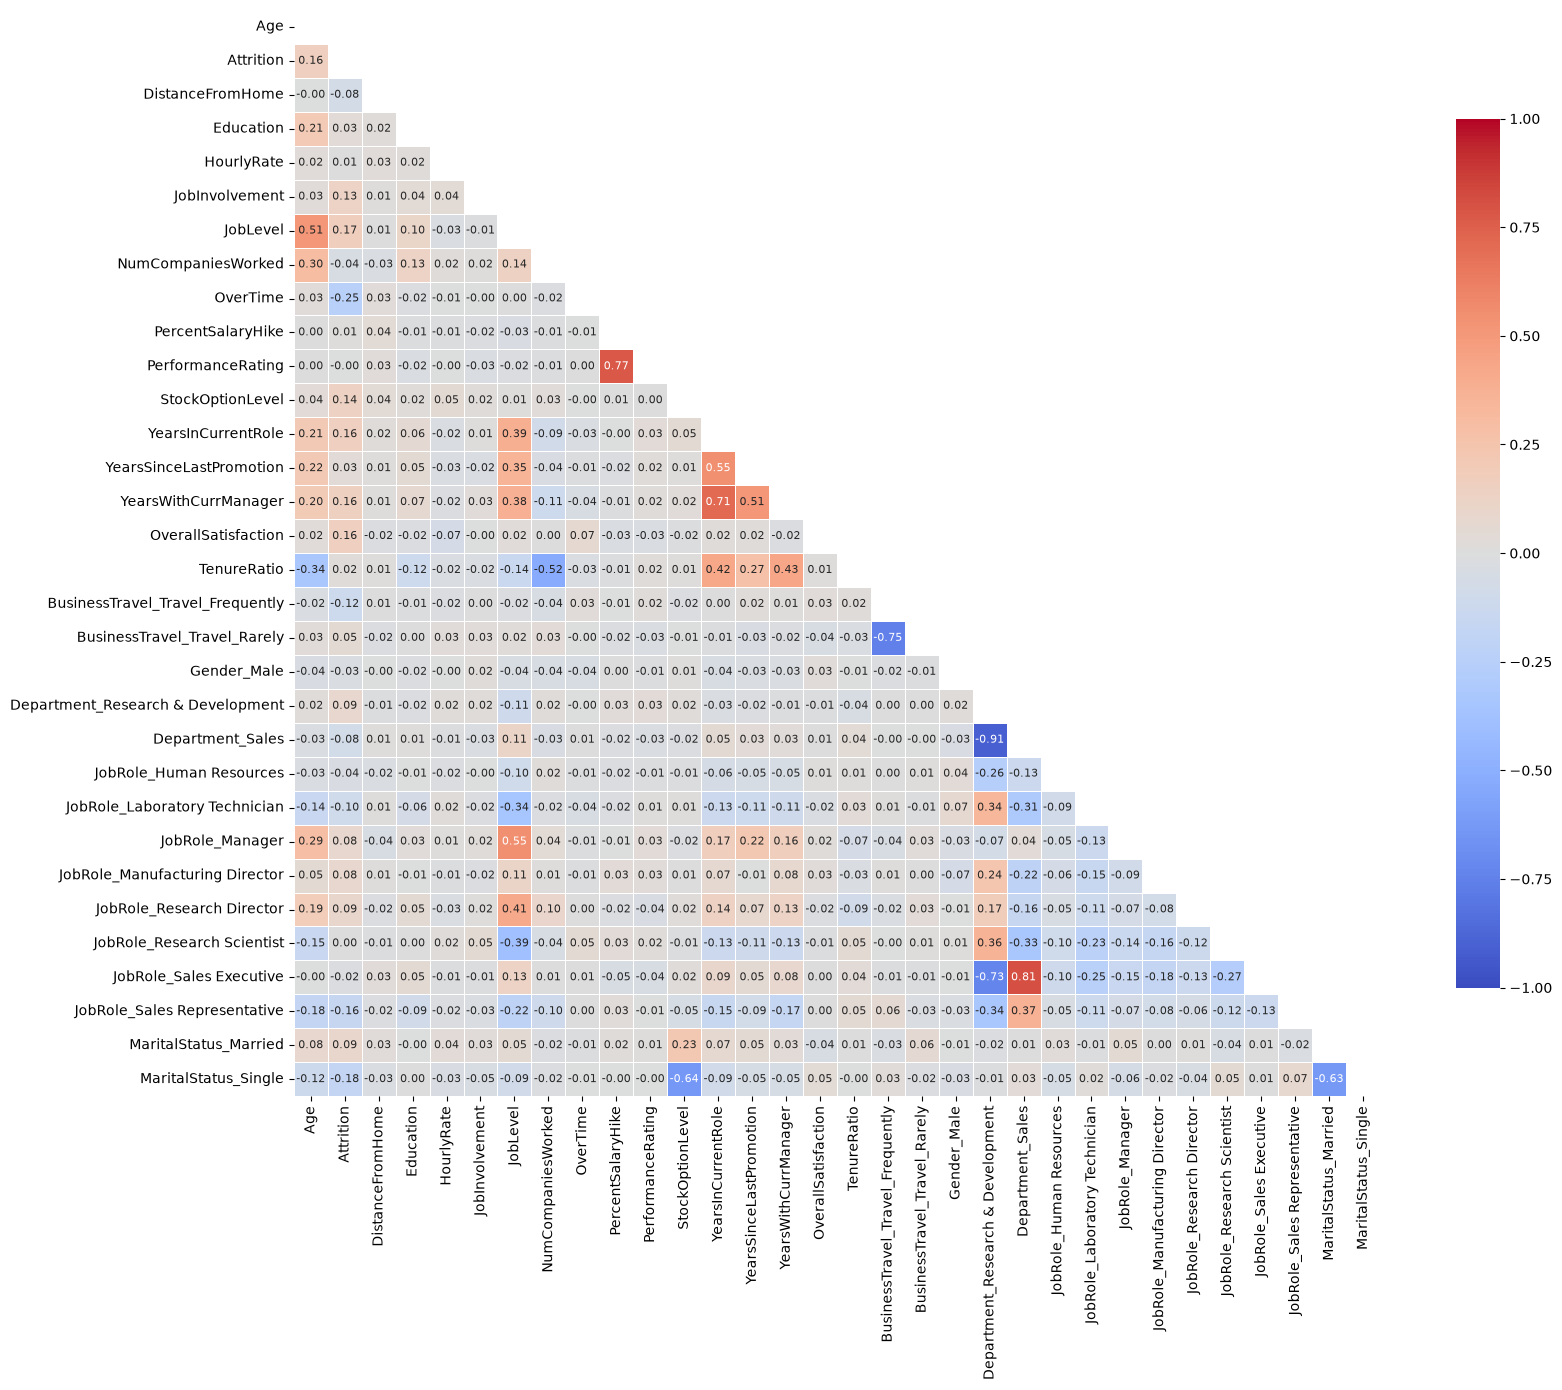

In [14]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Hide the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Larger figure
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
X_train_reduced = X_train_norm.drop(columns = ["Education","HourlyRate","NumCompaniesWorked","PercentSalaryHike","PerformanceRating",
    "YearsSinceLastPromotion","TenureRatio","Gender_Male","JobRole_Human Resources","JobRole_Research Scientist","JobRole_Sales Executive"])

X_test_reduced = X_test_norm.drop(columns = ["Education","HourlyRate","NumCompaniesWorked","PercentSalaryHike","PerformanceRating",
    "YearsSinceLastPromotion","TenureRatio","Gender_Male","JobRole_Human Resources","JobRole_Research Scientist","JobRole_Sales Executive"])

In [21]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train_reduced, y_train)
model.score(X_test_reduced, y_test)

0.7619047619047619

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

probability_attrition = model.predict_proba(X_test_reduced)[:, 0]

threshold = 0.66
y_pred = np.where(probability_attrition >= threshold, 0, 1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 34  15]
 [ 21 224]]
              precision    recall  f1-score   support

           0       0.62      0.69      0.65        49
           1       0.94      0.91      0.93       245

    accuracy                           0.88       294
   macro avg       0.78      0.80      0.79       294
weighted avg       0.88      0.88      0.88       294

